In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
print(f'Train accuracy: {tree.score(X_train, y_train):.2%}')
print(f'Test accuracy: {tree.score(X_test, y_test):.2%}')

Train accuracy: 95.00%
Test accuracy: 96.67%


In [ ]:
print(export_text(tree, feature_names=iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- class: 1
|   |--- petal length (cm) >  4.75
|   |   |--- class: 2



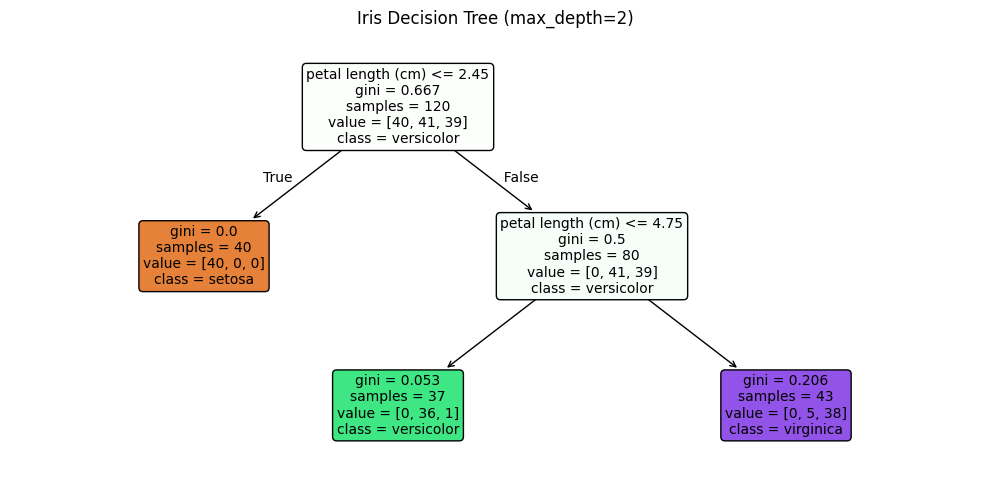

In [ ]:
plt.figure(figsize=(10, 5))
plot_tree(tree, feature_names=iris.feature_names,
class_names=iris.target_names,
filled=True, rounded=True, fontsize=10)
plt.title('Iris Decision Tree (max_depth=2)'); plt.tight_layout(); plt.show()


In [ ]:
new_flower = [[5.1, 3.5, 1.4, 0.2]] # sepal_len, sepal_wid, petal_len, petal_wid
pred = tree.predict(new_flower)[0]
print(f'Predicted species: {iris.target_names[pred]}')
print(f'Probabilities : {tree.predict_proba(new_flower)[0]}')

Predicted species: setosa
Probabilities : [1. 0. 0.]


Calculate Gini manually first, then let sklearn demonstrate the same logic:

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt


def gini_impurity(labels):
    """Calculate Gini impurity for a list of class labels."""
    labels = np.array(labels)
    n = len(labels)
    if n == 0: return 0
    classes = np.unique(labels)
    gini = 1.0
    for c in classes:
        p = np.sum(labels == c) / n # proportion of class c
        gini -= p ** 2
    return gini

In [ ]:
print('Pure node (all same) :', gini_impurity([1,1,1,1,1])) # 0.00
print('50-50 split :', gini_impurity([0,0,0,1,1,1])) # 0.50
print('70-30 split :', gini_impurity([0,0,0,0,0,0,0,1,1,1])) # 0.42
print('90-10 split :', gini_impurity([0]*9 + [1])) # 0.18

Pure node (all same) : 0.0
50-50 split : 0.5
70-30 split : 0.42000000000000004
90-10 split : 0.17999999999999994


In [ ]:
def weighted_gini(left_labels, right_labels):
    """Gini after a split — weighted by group size."""
    n_total = len(left_labels) + len(right_labels)
    w_left = len(left_labels) / n_total
    w_right = len(right_labels) / n_total
    return w_left * gini_impurity(left_labels) + w_right * gini_impurity(right_labels)

In [ ]:
left_A = [0,0,0,0,1]
right_A = [0,1,1,1,1]

In [ ]:
left_B = [0,0,1,1,0]
right_B = [0,1,0,1,1]

In [ ]:
print(f'Weighted Gini — Glucose split: {weighted_gini(left_A, right_A):.3f}')
print(f'Weighted Gini — Age split : {weighted_gini(left_B, right_B):.3f}')
print('Tree picks the split with LOWER weighted Gini → Glucose split is better!')

Weighted Gini — Glucose split: 0.320
Weighted Gini — Age split : 0.480
Tree picks the split with LOWER weighted Gini → Glucose split is better!


In [14]:
from sklearn.datasets import make_classification
from sklearn.tree import export_text
X, y = make_classification(n_samples=200, n_features=4, random_state=42)
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X, y)

print(export_text(tree, feature_names=['F1','F2','F3','F4']))

|--- F1 <= -0.15
|   |--- F3 <= -0.44
|   |   |--- class: 0
|   |--- F3 >  -0.44
|   |   |--- class: 0
|--- F1 >  -0.15
|   |--- F3 <= 0.63
|   |   |--- class: 1
|   |--- F3 >  0.63
|   |   |--- class: 0



In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=500, n_features=8, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
depths = range(1, 10)
train_acc, test_acc = [], []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))
best_depth = depths[test_acc.index(max(test_acc))]
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

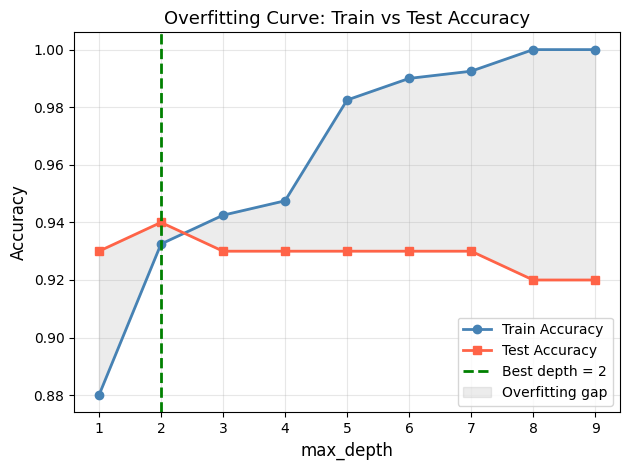

Best test accuracy 94.00% at depth=2


In [17]:
plt.plot(depths, train_acc, 'o-', color='steelblue', lw=2, label='Train Accuracy')
plt.plot(depths, test_acc, 's-', color='tomato', lw=2, label='Test Accuracy')
plt.axvline(x=best_depth, color='green', linestyle='--', lw=2,
            label=f'Best depth = {best_depth}')
plt.fill_between(depths,
                 train_acc, test_acc,
                 alpha=0.15, color='gray', label='Overfitting gap')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting Curve: Train vs Test Accuracy', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()



print(f'Best test accuracy {max(test_acc):.2%} at depth={best_depth}')

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

In [20]:
configs=[
    {'max_depth':None},
    {'max_depth':5},
    {'max_depth':5,'min_samples_split':10},
    {'max_depth':5,'min_samples_leaf':5},
    {'max_depth':4,'max_features': 'sqrt'},
]

print(f'{'Config':45s} {'CV Score (mean±std)':20s}')
print('-' * 68)

for cfg in configs:
    tree = DecisionTreeClassifier(**cfg ,random_state=42)
    scores = cross_val_score(tree,X, y, cv=5, scoring='accuracy')
    print(f'{str(cfg):45s} {scores.mean():.3f} +- {scores.std():.3f}')

Config                                        CV Score (mean±std) 
--------------------------------------------------------------------
{'max_depth': None}                           0.912 +- 0.017
{'max_depth': 5}                              0.920 +- 0.014
{'max_depth': 5, 'min_samples_split': 10}     0.934 +- 0.016
{'max_depth': 5, 'min_samples_leaf': 5}       0.928 +- 0.021
{'max_depth': 4, 'max_features': 'sqrt'}      0.912 +- 0.012
